# Recompute All Local-Level Flows (Milton + Helene)

**Purpose**: Correctly compute within, inflow, and outflow at the local level
(county for Milton, cluster for Helene) using the proper definitions.

**Definitions** (M[d, cat, dest, origin], A = all affected counties):

For local unit j (county or cluster of counties) within affected region A:
- **Within**: $W_j(t) = \sum_{d \in A} M(t,:,d,j)$ — trips FROM j TO anywhere in A (including j→j)
- **Outflow**: $O_j(t) = \sum_{d \notin A} M(t,:,d,j)$ — trips FROM j TO outside A
- **Inflow**: $I_j(t) = \sum_{o \notin A} M(t,:,j,o)$ — trips TO j FROM outside A

Note: Within + Outflow = total outgoing from j. This is NOT the same as
within-cluster (both endpoints in same cluster) which was the previous bug.

**Output**: `results/local_level/{milton,helene}/`

In [6]:
import pandas as pd
import numpy as np
import os
import sys
import datetime as dt
import warnings
from importlib import reload

import matplotlib.pyplot as plt

folder_path = './../../hurricane_oct/'
sys.path.append(folder_path)
sys.path.append(os.path.join(folder_path, 'mobility_function'))
from mobility_function import analysis as ma
ma = reload(ma)

%run ./recovery_function_v2.py

warnings.filterwarnings('ignore')

OUTPUT_MILTON = '../results/local_level/milton'
OUTPUT_HELENE = '../results/local_level/helene'
os.makedirs(os.path.join(OUTPUT_MILTON, 'figures'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_HELENE, 'figures'), exist_ok=True)

print('Setup complete.')

Setup complete.


In [7]:
# ── Date setup ──
def mondays_str(year, start_month=7, end_month=10):
    start = dt.date(year, start_month, 28)
    end = dt.date(year, end_month, 31)
    days_ahead = (0 - start.weekday()) % 7
    cur = start + dt.timedelta(days=days_ahead)
    out = []
    while cur <= end:
        out.append(cur.strftime('%Y%m%d'))
        cur += dt.timedelta(days=7)
    return out

mondays_2023 = mondays_str(2023)
mondays_2024 = mondays_str(2024)
all_mondays = mondays_2023 + mondays_2024

dates_2023 = pd.date_range(start='2023-07-31', periods=len(mondays_2023)*7, freq='D')
dates_2024 = pd.date_range(start='2024-07-29', periods=len(mondays_2024)*7, freq='D')
dates_all = dates_2023.union(dates_2024)

# County index mapping
geo_idx = pd.read_csv('geoid_idx_names.csv')
geo_idx['GEOID'] = geo_idx['GEOID'].astype(int)
total_counties = geo_idx['county_idx'].max() + 1  # total counties in M tensor

print(f'Mondays: {len(all_mondays)}, Total days: {len(dates_all)}')
print(f'Total counties in tensor: {total_counties}')

Mondays: 28, Total days: 196
Total counties in tensor: 3144


In [8]:
def compute_local_flows(M_sum, local_idx, all_A_idx):
    """
    Compute within, inflow, outflow for a local unit (county or cluster)
    relative to the full affected region A.
    
    Parameters:
    -----------
    M_sum : ndarray, shape (days, dest, origin) — category-summed mobility tensor
    local_idx : array of int — county indices belonging to this local unit
    all_A_idx : array of int — ALL county indices in the affected region A
    
    Returns:
    --------
    within : ndarray (days,) — trips FROM local TO A (including self)
    outflow : ndarray (days,) — trips FROM local TO outside A
    inflow : ndarray (days,) — trips FROM outside A TO local
    """
    n_total = M_sum.shape[1]  # total counties dimension
    
    # Masks
    A_mask = np.zeros(n_total, dtype=bool)
    A_mask[all_A_idx] = True
    outside_A_mask = ~A_mask
    
    # ── OUTGOING from local unit: M_sum[:, dest, local_idx] ──
    # Total outgoing from local to all destinations
    outgoing_all = M_sum[:, :, local_idx].sum(axis=2)  # (days, all_dest)
    
    # Within = outgoing to A destinations
    within = outgoing_all[:, A_mask].sum(axis=1)  # (days,)
    
    # Outflow = outgoing to outside-A destinations
    outflow = outgoing_all[:, outside_A_mask].sum(axis=1)  # (days,)
    
    # ── INCOMING to local unit: M_sum[:, local_idx, origin] ──
    incoming_all = M_sum[:, local_idx, :].sum(axis=1)  # (days, all_origin)
    
    # Inflow = incoming from outside-A origins
    inflow = incoming_all[:, outside_A_mask].sum(axis=1)  # (days,)
    
    return within, outflow, inflow

## 1. Milton — County-Level (N=21)

In [9]:
# ── Load Milton affected counties ──
with open(f'{OUTPUT_MILTON}/counties_geoid_cut_50.txt', 'r') as f:
    milton_geoids = [int(line.strip()) for line in f]

milton_counties = geo_idx[geo_idx['GEOID'].isin(milton_geoids)].copy()
milton_counties = milton_counties.sort_values('county_idx').reset_index(drop=True)
all_A_idx_milton = milton_counties['county_idx'].values

print(f'Milton: {len(all_A_idx_milton)} counties in A')
print(f'County indices: {all_A_idx_milton}')

Milton: 21 counties in A
County indices: [ 0  1  2  3  4  5  6  7  8  9 13 14 15 16 17 18 21 22 24 28 32]


In [10]:
# ── Compute all 3 flows for each Milton county ──
n_m = len(all_A_idx_milton)
m_within_ts = {i: [] for i in range(n_m)}
m_outflow_ts = {i: [] for i in range(n_m)}
m_inflow_ts = {i: [] for i in range(n_m)}

for date_str in all_mondays:
    print(f'  {date_str}...', end=' ', flush=True)
    M = ma.h5py_to_4d_array(folder_path + f'data/mobility/M_raw_{date_str}.h5')
    M_sum = M.sum(axis=1)  # (days, dest, origin)
    
    for j_id in range(n_m):
        local_idx = np.array([all_A_idx_milton[j_id]])  # single county
        w, o, i = compute_local_flows(M_sum, local_idx, all_A_idx_milton)
        m_within_ts[j_id].append(w)
        m_outflow_ts[j_id].append(o)
        m_inflow_ts[j_id].append(i)
    
    print('done')

# Concatenate
for j_id in range(n_m):
    m_within_ts[j_id] = np.concatenate(m_within_ts[j_id])
    m_outflow_ts[j_id] = np.concatenate(m_outflow_ts[j_id])
    m_inflow_ts[j_id] = np.concatenate(m_inflow_ts[j_id])

# Sanity check
print(f'\nSanity check (all values should be non-negative):')
for j_id in range(n_m):
    geoid = int(milton_counties.iloc[j_id]['GEOID'])
    name = milton_counties.iloc[j_id]['NAME']
    w_min = m_within_ts[j_id].min()
    o_min = m_outflow_ts[j_id].min()
    i_min = m_inflow_ts[j_id].min()
    flag = ' ⚠' if min(w_min, o_min, i_min) < 0 else ''
    print(f'  {name} ({geoid}): within={m_within_ts[j_id].mean():.0f}, '
          f'outflow={m_outflow_ts[j_id].mean():.0f}, '
          f'inflow={m_inflow_ts[j_id].mean():.0f}{flag}')

  20230731... done
  20230807... done
  20230814... done
  20230821... done
  20230828... done
  20230904... done
  20230911... done
  20230918... done
  20230925... done
  20231002... done
  20231009... done
  20231016... done
  20231023... done
  20231030... done
  20240729... done
  20240805... done
  20240812... done
  20240819... done
  20240826... done
  20240902... done
  20240909... done
  20240916... done
  20240923... done
  20240930... done
  20241007... done
  20241014... done
  20241021... done
  20241028... done

Sanity check (all values should be non-negative):
  Sarasota (12115): within=2336707, outflow=510013, inflow=285429
  Manatee (12081): within=1931489, outflow=396485, inflow=162300
  DeSoto (12027): within=119550, outflow=20883, inflow=7597
  Charlotte (12015): within=841269, outflow=191773, inflow=86262
  Hardee (12049): within=86302, outflow=10420, inflow=3409
  Hillsborough (12057): within=7811298, outflow=1351952, inflow=1239132
  Lee (12071): within=3680822,


############################################################
MILTON — WITHIN
############################################################
  Sarasota: drop=-33.1%, increase=11.7%, recovery=12d


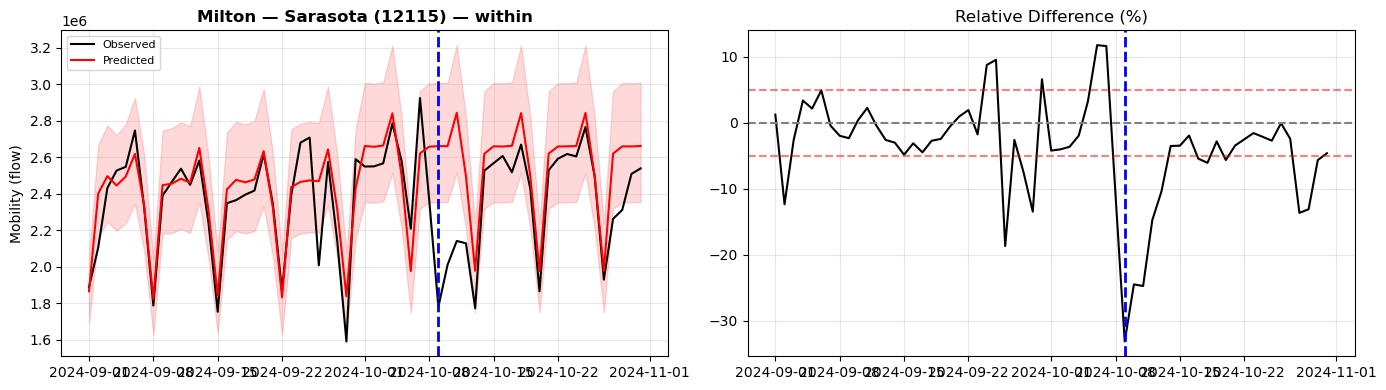

  Manatee: drop=-34.4%, increase=17.1%, recovery=4d


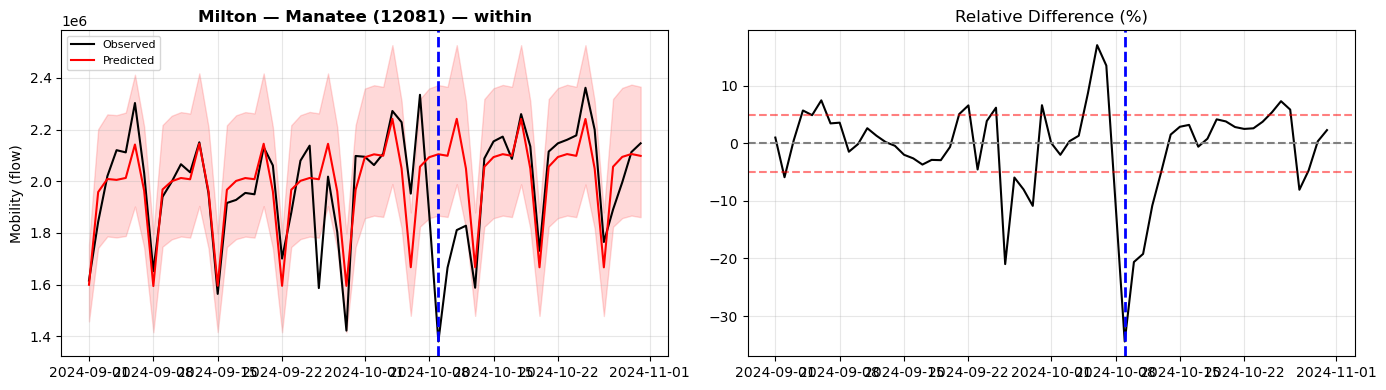

  DeSoto: drop=-43.1%, increase=15.6%, recovery=5d


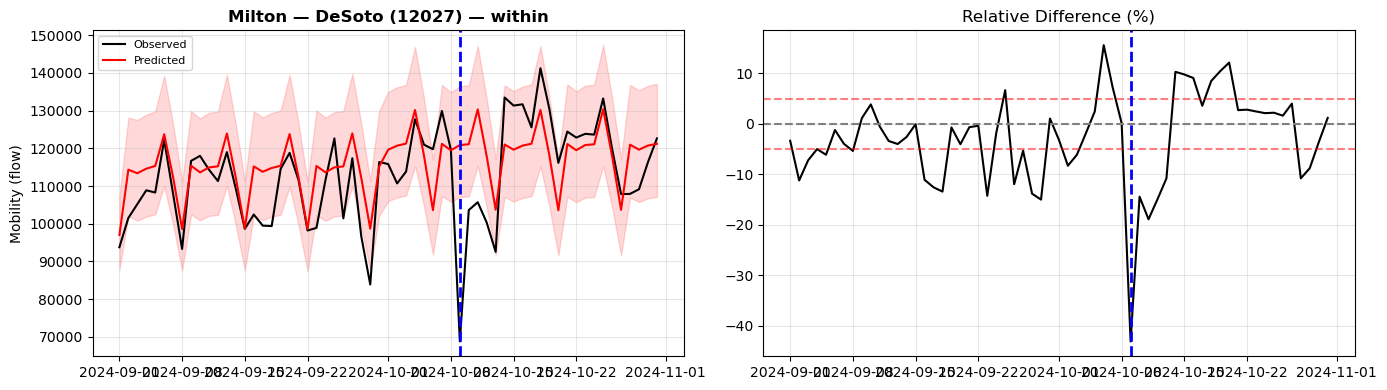

  Charlotte: drop=-47.3%, increase=21.2%, recovery=5d
  Hardee: drop=-24.5%, increase=28.4%, recovery=4d
  Hillsborough: drop=-41.6%, increase=14.4%, recovery=5d
  Lee: drop=-42.3%, increase=13.9%, recovery=5d
  Pinellas: drop=-34.4%, increase=15.9%, recovery=5d
  Polk: drop=-36.1%, increase=13.0%, recovery=5d
  Highlands: drop=-31.2%, increase=16.7%, recovery=5d
  Pasco: drop=-43.7%, increase=18.1%, recovery=5d
  Okeechobee: drop=-40.2%, increase=10.3%, recovery=Noned
  Osceola: drop=-35.7%, increase=23.1%, recovery=3d
  Sumter: drop=-37.6%, increase=22.3%, recovery=5d
  Lake: drop=-26.7%, increase=14.9%, recovery=5d
  Hernando: drop=-41.8%, increase=15.3%, recovery=5d
  Orange: drop=-33.2%, increase=16.3%, recovery=5d
  Indian River: drop=-23.2%, increase=16.2%, recovery=5d
  Brevard: drop=-25.0%, increase=17.5%, recovery=5d
  Seminole: drop=-30.9%, increase=15.3%, recovery=5d
  Volusia: drop=-29.2%, increase=14.3%, recovery=5d

  Saved: within — drop range [-47.3, -23.2]%, recovery 

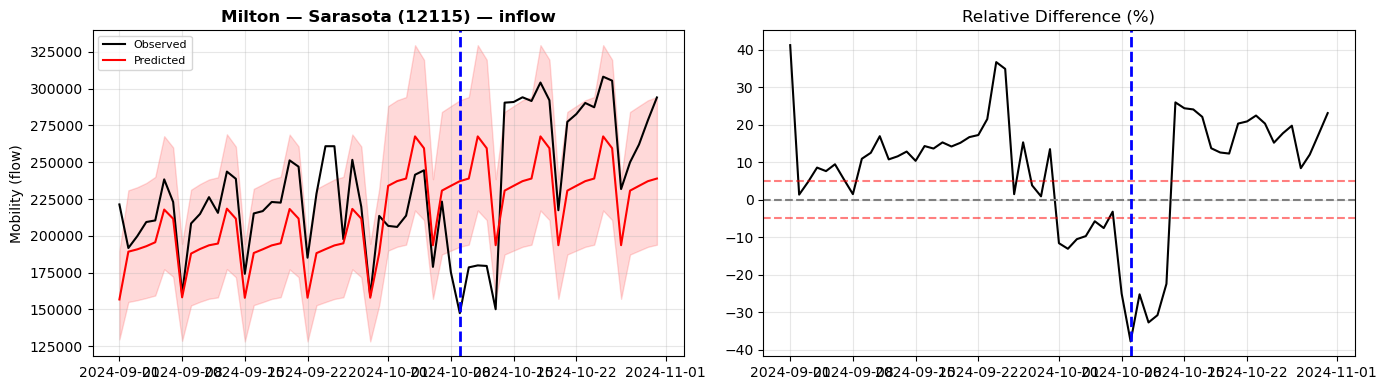

  Manatee: drop=-41.2%, increase=35.8%, recovery=5d


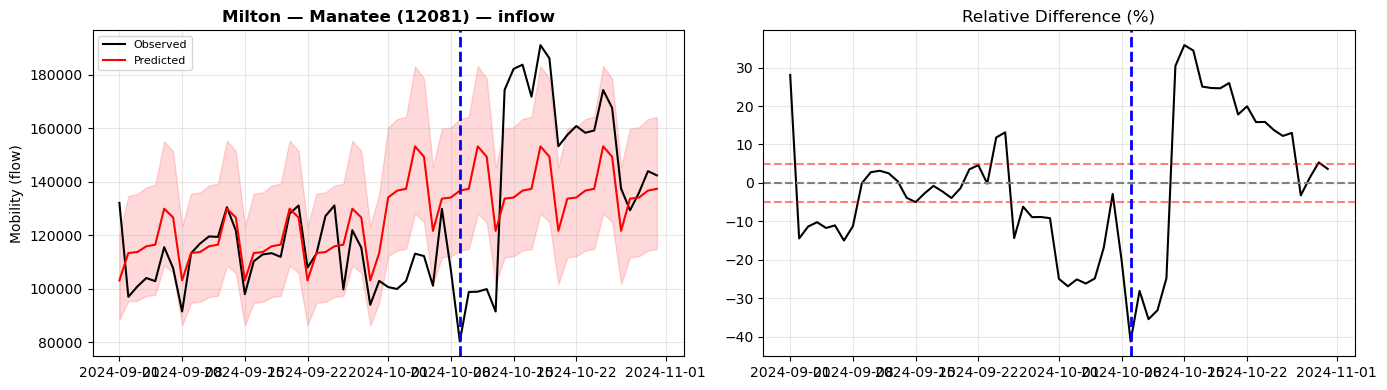

  DeSoto: drop=-28.9%, increase=59.5%, recovery=1d


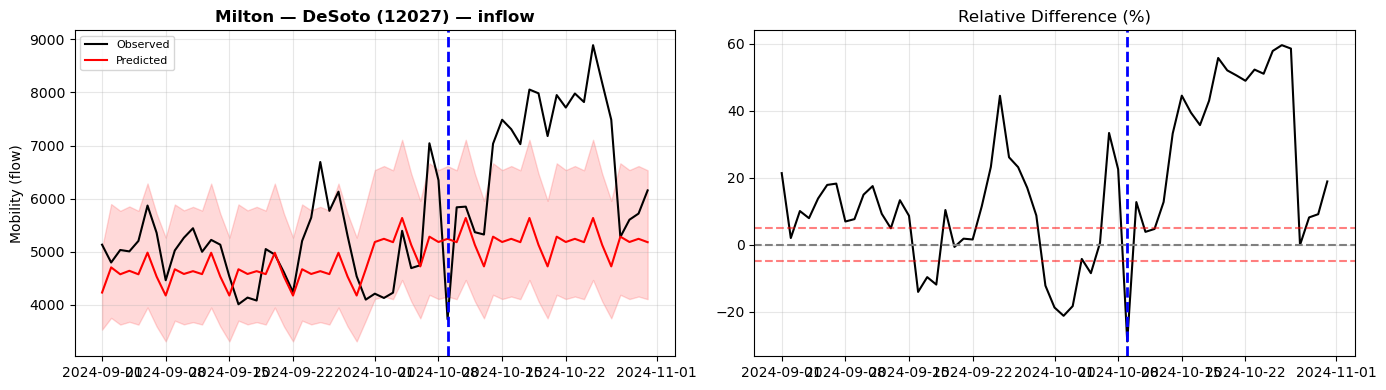

  Charlotte: drop=-39.2%, increase=39.2%, recovery=5d
  Hardee: drop=-43.0%, increase=64.3%, recovery=2d
  Hillsborough: drop=-67.6%, increase=38.2%, recovery=5d
  Lee: drop=-53.3%, increase=35.5%, recovery=5d
  Pinellas: drop=-53.9%, increase=32.1%, recovery=12d
  Polk: drop=-31.1%, increase=35.6%, recovery=3d
  Highlands: drop=-39.3%, increase=36.5%, recovery=10d
  Pasco: drop=-40.3%, increase=46.4%, recovery=5d
  Okeechobee: drop=-40.5%, increase=11.0%, recovery=5d
  Osceola: drop=-33.2%, increase=22.8%, recovery=5d
  Sumter: drop=-32.7%, increase=22.2%, recovery=3d
  Lake: drop=-26.1%, increase=33.0%, recovery=5d
  Hernando: drop=-27.7%, increase=29.0%, recovery=4d
  Orange: drop=-58.6%, increase=24.1%, recovery=5d
  Indian River: drop=-20.4%, increase=35.0%, recovery=4d
  Brevard: drop=-37.5%, increase=5.6%, recovery=5d
  Seminole: drop=-39.0%, increase=31.1%, recovery=Noned
  Volusia: drop=-27.0%, increase=50.0%, recovery=5d

  Saved: inflow — drop range [-67.6, -20.4]%, recovery

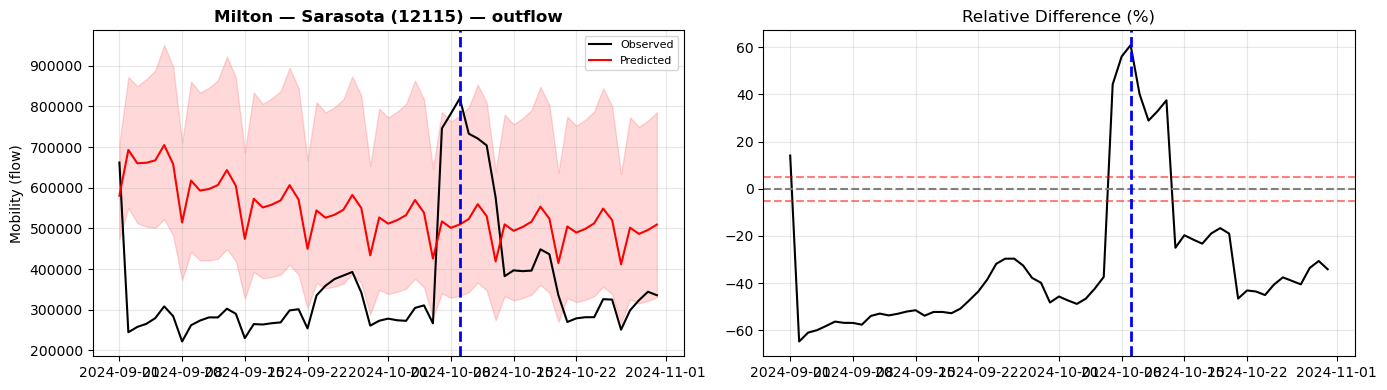

  Manatee: drop=-79.9%, increase=147.2%, recovery=Noned


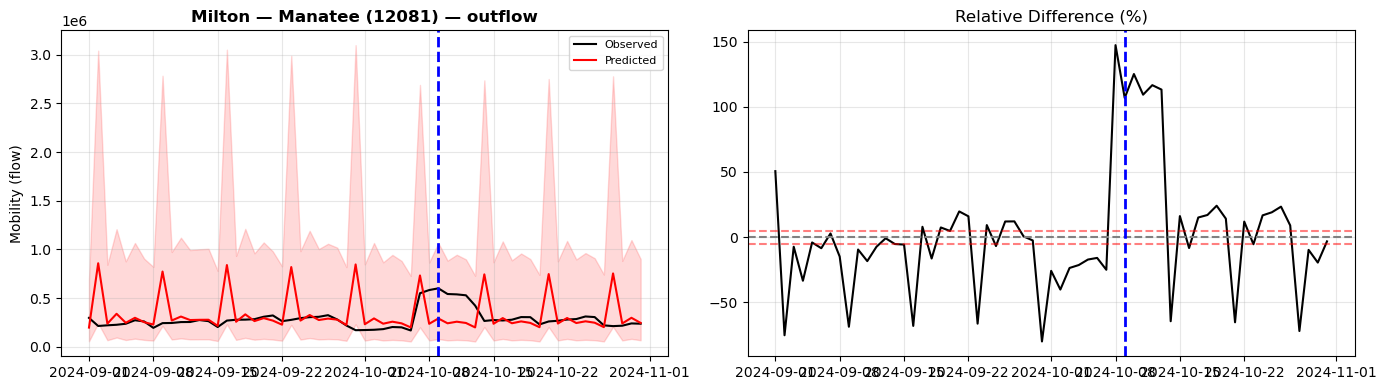

  DeSoto: drop=-75.4%, increase=50.1%, recovery=Noned


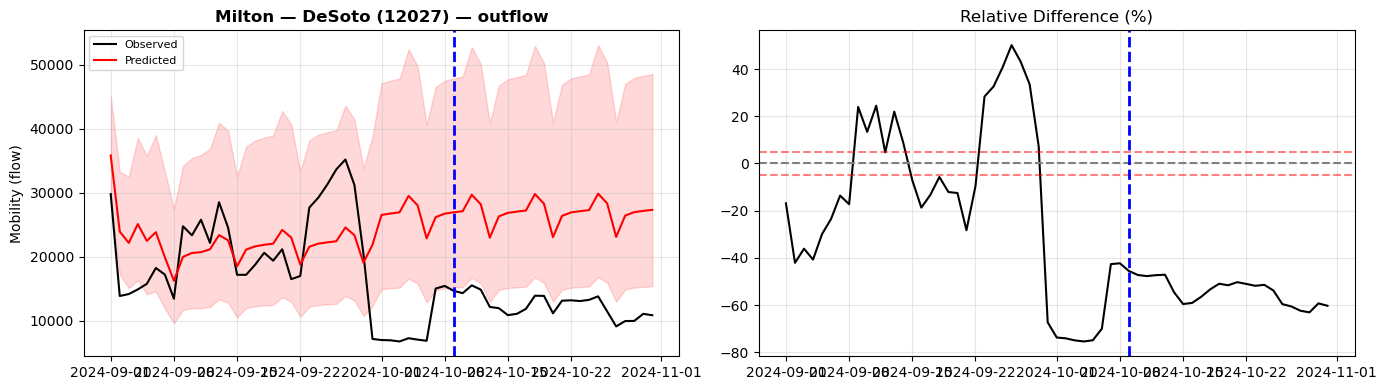

  Charlotte: drop=-33.9%, increase=130.8%, recovery=0d
  Hardee: drop=-66.3%, increase=77.3%, recovery=Noned
  Hillsborough: drop=-33.9%, increase=52.2%, recovery=12d
  Lee: drop=-30.4%, increase=37.2%, recovery=12d
  Pinellas: drop=-32.3%, increase=56.7%, recovery=Noned
  Polk: drop=-21.0%, increase=22.9%, recovery=0d
  Highlands: drop=-47.3%, increase=26.1%, recovery=12d
  Pasco: drop=-51.9%, increase=10.7%, recovery=Noned
  Okeechobee: drop=-16.5%, increase=40.1%, recovery=12d
  Osceola: drop=-38.2%, increase=14.0%, recovery=12d
  Sumter: drop=-11.4%, increase=49.2%, recovery=5d
  Lake: drop=-31.6%, increase=20.3%, recovery=5d
  Hernando: drop=-28.6%, increase=58.7%, recovery=9d
  Orange: drop=-20.7%, increase=22.7%, recovery=6d
  Indian River: drop=-25.2%, increase=49.8%, recovery=0d
  Brevard: drop=-24.4%, increase=35.6%, recovery=5d
  Seminole: drop=-39.2%, increase=-1.8%, recovery=Noned
  Volusia: drop=-28.9%, increase=27.5%, recovery=Noned

  Saved: outflow — drop range [-79.9,

In [11]:
# ── SARIMAX + metrics for all 3 flows × 21 counties ──
LANDING_M = pd.Timestamp('2024-10-09')
TRAIN_END_M = '2024-08-31'
ARIMA_ORDER = (2, 0, 2)
SEASONAL_ORDER = (1, 0, 1, 7)

FLOW_DATA_M = {
    'within': m_within_ts,
    'inflow': m_inflow_ts,
    'outflow': m_outflow_ts,
}

for flow_name, flow_ts in FLOW_DATA_M.items():
    print(f"\n{'#'*60}")
    print(f'MILTON — {flow_name.upper()}')
    print(f"{'#'*60}")
    
    drop_results = []
    recovery_results = []
    
    for j_id in range(n_m):
        geoid = int(milton_counties.iloc[j_id]['GEOID'])
        name = milton_counties.iloc[j_id]['NAME']
        flow_y = flow_ts[j_id]
        
        try:
            y_log, y, X = prepare_time_series_with_exog(flow_y, dates_all)
            res, y_train, X_train = fit_arimax_model(
                y_log, X, order=ARIMA_ORDER, seasonal_order=SEASONAL_ORDER,
                train_2024_end=TRAIN_END_M)
            df_rec, forecast_idx = get_predictions_and_ci(
                res, X, y, forecast_start='2024-09-01', forecast_end='2024-10-31')
            
            result = recovery_time_from_largest_drop(
                df_rec, k=7, delta=0.05, side='lower', landing_date=LANDING_M)
            
            rel_diff = result.get('relative_diff')
            largest_drop = float(rel_diff.min()) if rel_diff is not None else None
            
            # For outflow: also compute largest INCREASE
            largest_increase = float(rel_diff.max()) if rel_diff is not None else None
            
            drop_results.append({
                'GEOID': geoid,
                'largest_drop': largest_drop,
                'largest_increase': largest_increase,
                'trough_date': result.get('trough_date'),
            })
            recovery_results.append({
                'GEOID': geoid,
                'recovery_days': result.get('recovery_days'),
                'trough_date': result.get('trough_date'),
                'recovery_date': result.get('recovery_date'),
            })
            
            print(f'  {name}: drop={largest_drop:.1f}%, increase={largest_increase:.1f}%, '
                  f'recovery={result.get("recovery_days")}d')
            
            # Plot predicted vs actual for first 3 counties
            if j_id < 3:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
                ax1.plot(df_rec.index, df_rec['y_true'], 'k-', lw=1.5, label='Observed')
                ax1.plot(df_rec.index, df_rec['y_pred'], 'r-', lw=1.5, label='Predicted')
                ax1.fill_between(df_rec.index, df_rec['ci_lower'], df_rec['ci_upper'],
                                color='red', alpha=0.15)
                ax1.axvline(LANDING_M, color='blue', ls='--', lw=2)
                ax1.set_title(f'Milton — {name} ({geoid}) — {flow_name}', fontweight='bold')
                ax1.set_ylabel('Mobility (flow)')
                ax1.legend(fontsize=8)
                ax1.grid(True, alpha=0.3)
                
                if rel_diff is not None:
                    ax2.plot(forecast_idx, rel_diff.values, 'k-', lw=1.5)
                    ax2.axhline(0, color='gray', ls='--')
                    ax2.axhline(5, color='red', ls='--', alpha=0.5)
                    ax2.axhline(-5, color='red', ls='--', alpha=0.5)
                    ax2.axvline(LANDING_M, color='blue', ls='--', lw=2)
                ax2.set_title('Relative Difference (%)')
                ax2.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(f'{OUTPUT_MILTON}/figures/{flow_name}_{geoid}_pred_vs_actual.png',
                           dpi=100, bbox_inches='tight')
                plt.show()
        
        except Exception as e:
            print(f'  {name}: FAILED — {e}')
            drop_results.append({'GEOID': geoid, 'largest_drop': None,
                                 'largest_increase': None, 'trough_date': None})
            recovery_results.append({'GEOID': geoid, 'recovery_days': None,
                                     'trough_date': None, 'recovery_date': None})
    
    # Save
    drop_df = pd.DataFrame(drop_results)
    rec_df = pd.DataFrame(recovery_results)
    drop_df.to_csv(f'{OUTPUT_MILTON}/largest_drop_{flow_name}.csv', index=False)
    rec_df.to_csv(f'{OUTPUT_MILTON}/recovery_{flow_name}.csv', index=False)
    
    valid = drop_df['largest_drop'].dropna()
    print(f'\n  Saved: {flow_name} — drop range [{valid.min():.1f}, {valid.max():.1f}]%, '
          f'recovery NaN: {rec_df["recovery_days"].isna().sum()}/{len(rec_df)}')

## 2. Helene — Cluster-Level

In [12]:
# ── Load Helene cluster assignments ──
cluster_df = pd.read_csv(f'{OUTPUT_HELENE}/county_cluster_assignments.csv')
cluster_df['GEOID'] = cluster_df['GEOID'].astype(int)
cluster_df = cluster_df.merge(geo_idx[['GEOID', 'county_idx']], on='GEOID', how='left')
assert cluster_df['county_idx'].notna().all(), 'Some counties missing from geo_idx!'
cluster_df['county_idx'] = cluster_df['county_idx'].astype(int)

# ALL affected counties in A (the full Helene region)
all_A_idx_helene = cluster_df['county_idx'].values

# Cluster → county indices
cluster_indices = {}
for c, grp in cluster_df.groupby('cluster'):
    cluster_indices[c] = grp['county_idx'].values

print(f'Helene: {len(cluster_indices)} clusters, {len(all_A_idx_helene)} counties in A')

Helene: 38 clusters, 271 counties in A


In [13]:
# ── Compute all 3 flows for each Helene cluster ──
# Key difference from before: within = from cluster to ALL of A, not just within-cluster

h_within_ts = {c: [] for c in cluster_indices}
h_outflow_ts = {c: [] for c in cluster_indices}
h_inflow_ts = {c: [] for c in cluster_indices}

for date_str in all_mondays:
    print(f'  {date_str}...', end=' ', flush=True)
    M = ma.h5py_to_4d_array(folder_path + f'data/mobility/M_raw_{date_str}.h5')
    M_sum = M.sum(axis=1)  # (days, dest, origin)
    
    for c, c_idx in cluster_indices.items():
        w, o, i = compute_local_flows(M_sum, c_idx, all_A_idx_helene)
        h_within_ts[c].append(w)
        h_outflow_ts[c].append(o)
        h_inflow_ts[c].append(i)
    
    print('done')

# Concatenate
for c in cluster_indices:
    h_within_ts[c] = np.concatenate(h_within_ts[c])
    h_outflow_ts[c] = np.concatenate(h_outflow_ts[c])
    h_inflow_ts[c] = np.concatenate(h_inflow_ts[c])

# Sanity check
print(f'\nSanity check (first 5 clusters):')
for c in sorted(cluster_indices.keys())[:5]:
    n_c = len(cluster_indices[c])
    w_min = h_within_ts[c].min()
    o_min = h_outflow_ts[c].min()
    i_min = h_inflow_ts[c].min()
    flag = ' ⚠' if min(w_min, o_min, i_min) < 0 else ''
    print(f'  Cluster {c} ({n_c} counties): within={h_within_ts[c].mean():.0f}, '
          f'outflow={h_outflow_ts[c].mean():.0f}, '
          f'inflow={h_inflow_ts[c].mean():.0f}{flag}')

  20230731... done
  20230807... done
  20230814... done
  20230821... done
  20230828... done
  20230904... done
  20230911... done
  20230918... done
  20230925... done
  20231002... done
  20231009... done
  20231016... done
  20231023... done
  20231030... done
  20240729... done
  20240805... done
  20240812... done
  20240819... done
  20240826... done
  20240902... done
  20240909... done
  20240916... done
  20240923... done
  20240930... done
  20241007... done
  20241014... done
  20241021... done
  20241028... done

Sanity check (first 5 clusters):
  Cluster 0 (2 counties): within=8040893, outflow=1507672, inflow=4712181
  Cluster 1 (30 counties): within=12529374, outflow=7727359, inflow=2603285
  Cluster 2 (30 counties): within=11283609, outflow=2208012, inflow=2131462
  Cluster 3 (35 counties): within=5669607, outflow=1380889, inflow=727490
  Cluster 4 (5 counties): within=653560, outflow=131701, inflow=87581


In [ ]:
# ── SARIMAX + metrics for all 3 flows × all Helene clusters ──
LANDING_H = pd.Timestamp('2024-09-26')
TRAIN_END_H = '2024-09-19'

FLOW_DATA_H = {
    'within': h_within_ts,
    'inflow': h_inflow_ts,
    'outflow': h_outflow_ts,
}

# Load ACS and merge ONLY extra columns not already in cluster_df
acs = pd.read_csv('acs_socioeconomic_v2.csv')
acs['GEOID'] = acs['GEOID'].astype(int)

# Columns already in cluster_df: GEOID, NAME, cluster, nchs_code, nchs_label,
# median_household_income, total_population, dist_to_track_mi, largest_drop
# Only merge columns that are NEW
extra_cols = ['GEOID', 'pct_no_vehicle', 'insurance_coverage_pct',
              'pct_white', 'pct_bachelors_plus', 'white_pop', 'bachelors_plus_count']
cluster_df_feat = cluster_df.merge(acs[extra_cols], on='GEOID', how='left')

# Compute cluster-level features
cluster_features = cluster_df_feat.groupby('cluster').apply(
    lambda g: pd.Series({
        'n_counties': len(g),
        'total_pop': g['total_population'].sum(),
        'median_income': g['median_household_income'].median(),
        'cluster_pct_white': g['white_pop'].sum() / g['total_population'].sum() * 100
            if g['total_population'].sum() > 0 else None,
        'cluster_pct_bachelors': g['bachelors_plus_count'].sum() / g['total_population'].sum() * 100
            if g['total_population'].sum() > 0 else None,
        'median_pct_no_vehicle': g['pct_no_vehicle'].median(),
        'median_insurance': g['insurance_coverage_pct'].median(),
        'mean_dist_to_track': g['dist_to_track_mi'].mean(),
        'nchs_code': g['nchs_code'].mode().iloc[0] if len(g['nchs_code'].mode()) > 0 else None,
    })
).reset_index()

print(f'Cluster features computed: {len(cluster_features)} clusters')
print(cluster_features.head())

In [ ]:
# ── Run SARIMAX for each flow type ──
for flow_name, flow_ts in FLOW_DATA_H.items():
    print(f"\n{'#'*60}")
    print(f'HELENE — {flow_name.upper()}')
    print(f"{'#'*60}")
    
    results_list = []
    
    for c in sorted(cluster_indices.keys()):
        n_counties = len(cluster_indices[c])
        flow_y = flow_ts[c]
        
        try:
            y_log, y, X = prepare_time_series_with_exog(flow_y, dates_all)
            res, y_train, X_train = fit_arimax_model(
                y_log, X, order=ARIMA_ORDER, seasonal_order=SEASONAL_ORDER,
                train_2024_end=TRAIN_END_H)
            df_rec, forecast_idx = get_predictions_and_ci(
                res, X, y, forecast_start='2024-09-01', forecast_end='2024-10-31')
            
            result = recovery_time_from_largest_drop(
                df_rec, k=7, delta=0.05, side='lower', landing_date=LANDING_H)
            
            rel_diff = result.get('relative_diff')
            largest_drop = float(rel_diff.min()) if rel_diff is not None else None
            largest_increase = float(rel_diff.max()) if rel_diff is not None else None
            
            # Get cluster features
            cf = cluster_features[cluster_features['cluster'] == c]
            row = {
                'cluster': c,
                'n_counties': n_counties,
                'largest_drop': largest_drop,
                'largest_increase': largest_increase,
                'trough_date': result.get('trough_date'),
                'recovery_days': result.get('recovery_days'),
                'recovery_date': result.get('recovery_date'),
            }
            if len(cf) > 0:
                for col in cf.columns:
                    if col != 'cluster' and col not in row:
                        row[col] = cf.iloc[0][col]
            
            results_list.append(row)
            print(f'  Cluster {c} ({n_counties}): drop={largest_drop:.1f}%, '
                  f'increase={largest_increase:.1f}%, rec={result.get("recovery_days")}d')
            
            # Plot first 3 clusters
            if c < 3:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
                ax1.plot(df_rec.index, df_rec['y_true'], 'k-', lw=1.5, label='Observed')
                ax1.plot(df_rec.index, df_rec['y_pred'], 'r-', lw=1.5, label='Predicted')
                ax1.fill_between(df_rec.index, df_rec['ci_lower'], df_rec['ci_upper'],
                                color='red', alpha=0.15)
                ax1.axvline(LANDING_H, color='blue', ls='--', lw=2)
                ax1.set_title(f'Helene Cluster {c} — {flow_name} ({n_counties} counties)',
                             fontweight='bold')
                ax1.legend(fontsize=8)
                ax1.grid(True, alpha=0.3)
                
                if rel_diff is not None:
                    ax2.plot(forecast_idx, rel_diff.values, 'k-', lw=1.5)
                    ax2.axhline(0, color='gray', ls='--')
                    ax2.axvline(LANDING_H, color='blue', ls='--', lw=2)
                ax2.set_title('Relative Difference (%)')
                ax2.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(f'{OUTPUT_HELENE}/figures/{flow_name}_cluster_{c}.png',
                           dpi=100, bbox_inches='tight')
                plt.show()
        
        except Exception as e:
            print(f'  Cluster {c}: FAILED — {e}')
            results_list.append({
                'cluster': c, 'n_counties': n_counties,
                'largest_drop': None, 'largest_increase': None,
                'recovery_days': None,
            })
    
    # Save
    rdf = pd.DataFrame(results_list)
    rdf.to_csv(f'{OUTPUT_HELENE}/cluster_results_{flow_name}.csv', index=False)
    
    valid = rdf['largest_drop'].dropna()
    print(f'\n  Saved: {flow_name} — drop range [{valid.min():.1f}, {valid.max():.1f}]%, '
          f'recovery NaN: {rdf["recovery_days"].isna().sum()}/{len(rdf)}')

## 3. Summary

In [ ]:
print('='*60)
print('RECOMPUTATION COMPLETE')
print('='*60)

print(f'\nResults saved to:')
print(f'  {OUTPUT_MILTON}/')
for f in sorted(os.listdir(OUTPUT_MILTON)):
    if f.endswith('.csv'):
        print(f'    {f}')

print(f'\n  {OUTPUT_HELENE}/')
for f in sorted(os.listdir(OUTPUT_HELENE)):
    if f.endswith('.csv'):
        print(f'    {f}')

print(f'\nFlow definitions used:')
print(f'  Within_j = sum_{{d in A}} M[t,:,d,j] — from j to A (including self)')
print(f'  Outflow_j = sum_{{d not in A}} M[t,:,d,j] — from j to outside A')
print(f'  Inflow_j = sum_{{o not in A}} M[t,:,j,o] — from outside A to j')